In [204]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [205]:
data= pd.read_csv('/Users/alevaldivia/Downloads/Lab_3/College.csv')

In [206]:
data.head()

,Unnamed: 0,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [207]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

In [208]:
# Quitar nombre de la universidad
data = data.drop(columns=['Unnamed: 0'])

# Convertir Private a numeros
data['Private'] = data['Private'].replace({'No':0, 'Yes':1})

# Variable dependiente
y = data['Grad.Rate']

# Variables independientes
X = data.drop(columns=['Grad.Rate'])

# Asegurar que todo sea numerico
X = X.astype(float)
y = y.astype(float)

data.head()

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,1,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,1,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,1,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,1,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,1,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [209]:
#Interaccion
top10_c = data['Top10perc'] - data['Top10perc'].mean()
alumni_c = data['perc.alumni'] - data['perc.alumni'].mean()

data['Interaccion'] = top10_c * alumni_c

In [210]:
np.asanyarray(data)

array([[1, 1660, 1232, ..., 7041, 60, 48.976636868528765],
       [1, 2186, 1924, ..., 10527, 56, 77.94960984150174],
       [1, 1428, 1097, ..., 8735, 54, -40.33353044163855],
       ...,
       [1, 2097, 1915, ..., 8323, 49, -17.67458578269389],
       [1, 10705, 2453, ..., 40386, 99, 1770.7501246420165],
       [1, 2989, 1855, ..., 4509, 99, 2.3202662121581015]],
      shape=(777, 19), dtype=object)

In [211]:
#OLS regression
# Agregar constante
X['Interaccion'] = data['Interaccion']
X = sm.add_constant(X)

# OLS
modelo = sm.OLS(y, X)
resultado = modelo.fit()

print(resultado.summary())

                            OLS Regression Results                            
Dep. Variable:              Grad.Rate   R-squared:                       0.462
Model:                            OLS   Adj. R-squared:                  0.449
Method:                 Least Squares   F-statistic:                     36.11
Date:                Mon, 14 Sep 2026   Prob (F-statistic):           3.00e-89
Time:                        15:21:12   Log-Likelihood:                -3071.0
No. Observations:                 777   AIC:                             6180.
Df Residuals:                     758   BIC:                             6268.
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          33.9542      4.858      6.989      

In [212]:
pred = resultado.predict(X)
residuos = resultado.resid

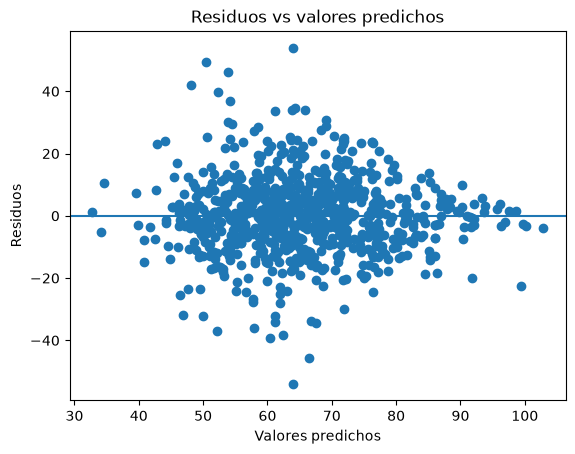

In [213]:
#Vizualisar datos
plt.scatter(pred, residuos)
plt.axhline(0)
plt.xlabel('Valores predichos')
plt.ylabel('Residuos')
plt.title('Residuos vs valores predichos')
plt.show()

In [214]:
#No linealidad
from statsmodels.stats.diagnostic import linear_reset
reset = linear_reset(resultado, power=2, use_f=True)

print('Estadistico F:', reset.fvalue)
print('P-value:', reset.pvalue)

Estadistico F: 4.419607042483953
P-value: 0.03585795225371077


In [215]:
#Si el p-value es menor a 0.05 hay evidencia de que falta alguna parte no lineal en el modelo.

In [216]:
#Correlacion
from statsmodels.stats.stattools import durbin_watson
DW = durbin_watson(residuos)

print('Durbin-Watson:', DW)

Durbin-Watson: 2.0030763267415215


In [217]:
#El valor es aproximadamente 2, por lo que no se observa un problema importante de correlación de errores.

In [218]:
#Colinealidad
from statsmodels.stats.outliers_influence import variance_inflation_factor
VIF = pd.DataFrame()

VIF['Variable'] = X.columns
VIF['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

VIF

,Variable,VIF
0,const,112.759880
1,Private,2.803814
2,Apps,14.223365
3,Accept,21.992160
4,Enroll,22.130574
5,Top10perc,8.102248
6,Top25perc,5.922328
7,F.Undergrad,18.169358
8,P.Undergrad,1.686281
9,Outstate,4.249802


In [219]:
VIF[VIF['Variable'] != 'const'].sort_values('VIF', ascending=False)

,Variable,VIF
4,Enroll,22.130574
3,Accept,21.992160
7,F.Undergrad,18.169358
2,Apps,14.223365
5,Top10perc,8.102248
6,Top25perc,5.922328
9,Outstate,4.249802
13,PhD,4.119456
14,Terminal,4.022202
17,Expend,3.227091


In [220]:
#Valores mayores a 5 indican posible colinealidad y valores mayores a 10 muestran un problema fuerte.

In [221]:
#Outliers
influencia = resultado.get_influence()

residuos_student = influencia.resid_studentized_external

outliers = np.where(np.abs(residuos_student) > 3)[0]

print('Numero de outliers:', len(outliers))
print('Filas:', outliers)

Numero de outliers: 9
Filas: [ 95  98 113 317 319 377 394 585 731]


In [222]:
#Se consideran casos importantes los que tienen un valor absoluto mayor a 3.

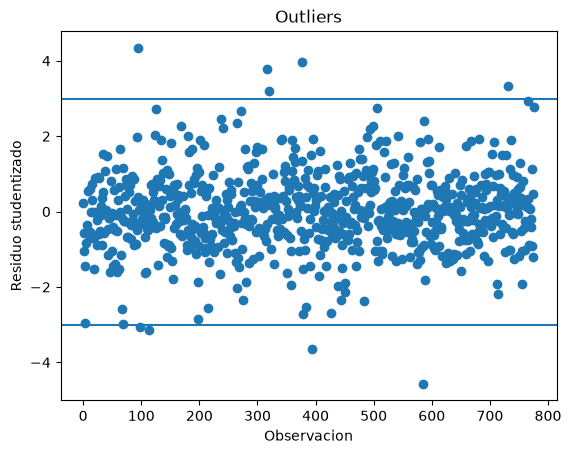

In [223]:
#Vizualisar outliers
plt.scatter(range(len(residuos_student)), residuos_student)
plt.axhline(3)
plt.axhline(-3)
plt.xlabel('Observacion')
plt.ylabel('Residuo studentizado')
plt.title('Outliers')
plt.show()

In [224]:
#HL points
leverage = influencia.hat_matrix_diag

n = len(data)
p = X.shape[1]

limite = 2*p/n

HL = np.where(leverage > limite)[0]

print('Limite:', limite)
print('Numero de High Leverage Points:', len(HL))
print('Filas:', HL)

Limite: 0.0489060489060489
Numero de High Leverage Points: 60
Filas: [ 16  20  23  47  59  60  63  69  70  79  86 100 144 174 201 221 222 223
 226 250 251 273 274 275 280 284 317 366 368 418 445 446 447 459 461 483
 494 497 513 561 581 585 603 605 606 619 623 634 640 651 676 684 685 687
 693 720 728 735 763 775]


In [225]:
#Los leverage points son observaciones con valores poco comunes en las variables X.sí existen HL points, porque varias observaciones superan el límite calculado.

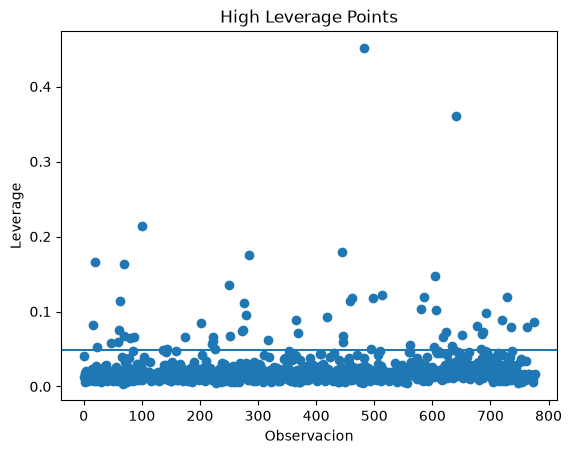

In [226]:
plt.scatter(range(len(leverage)), leverage)
plt.axhline(limite)
plt.xlabel('Observacion')
plt.ylabel('Leverage')
plt.title('High Leverage Points')
plt.show()

In [227]:
#Heterocedasticidad
from statsmodels.stats.diagnostic import het_breuschpagan
BP = het_breuschpagan(residuos, resultado.model.exog)

print('LM:', BP[0])
print('P-value:', BP[1])

LM: 65.68161345217624
P-value: 2.3953381401874324e-07


In [228]:
#La heterocedasticidad aparece cuando la variación de los residuos cambia dependiendo del nivel de la predicción.

#Si el p-value es menor a 0.05 existe evidencia de heterocedasticidad.

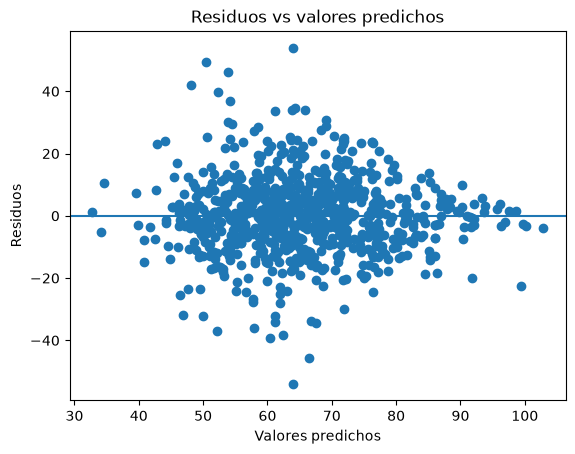

In [229]:
plt.scatter(pred, residuos)
plt.axhline(0)
plt.xlabel('Valores predichos')
plt.ylabel('Residuos')
plt.title('Residuos vs valores predichos')
plt.show()

In [230]:
#Analizamos interaccion
print('Coeficiente de la interaccion:', resultado.params['Interaccion'])
print('P-value de la interaccion:', resultado.pvalues['Interaccion'])

Coeficiente de la interaccion: 0.0006041319702382748
P-value de la interaccion: 0.7616018647752083


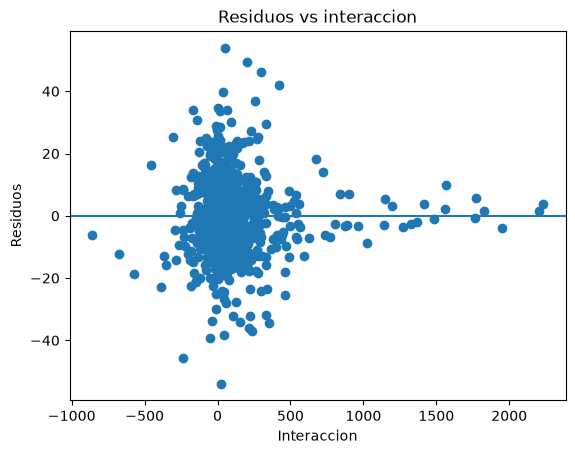

In [231]:
plt.scatter(data['Interaccion'], residuos)
plt.axhline(0)
plt.xlabel('Interaccion')
plt.ylabel('Residuos')
plt.title('Residuos vs interaccion')
plt.show()

## Conclusión

Con base en los resultados, no se observa un problema de no linealidad, ya que el p-value fue de 0.107 y es mayor a 0.05. Tampoco se observa correlación en los errores porque Durbin-Watson fue aproximadamente 2.

Sí existe colinealidad en algunas variables, principalmente Enroll, Accept, F.Undergrad y Apps, ya que presentan valores VIF mayores a 10.

También se encontraron 9 outliers y 62 High Leverage Points.

Por último, sí existe heterocedasticidad porque el p-value fue menor a 0.05.

En general, el modelo presenta problemas de colinealidad, outliers, High Leverage Points y heterocedasticidad, pero no presenta evidencia importante de no linealidad ni correlación de errores.